MODEL


In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import shap

In [ ]:
# Date bounds
START_DATE  = pd.Timestamp("2022-01-01")
CUTOFF_DATE = pd.Timestamp("2025-04-01")  # hold‑out month
TARGET      = "crime_count"

In [ ]:
# Load data

pd.set_option("display.max_columns", None)
df = pd.read_csv("/content/final-data-2022 copy.csv")

In [ ]:
# Convert to datetime and sort

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df = df.sort_values(["LSOA code", "Date"])

In [ ]:
# Creating months_since_last_crime feature

# Build a simple month index
min_year = df['Date'].dt.year.min()
df['month_idx'] = ((df['Date'].dt.year - min_year) * 12
                  + df['Date'].dt.month)

# Mark the month_idx only when a burglary occurred
df['last_crime_month_idx'] = df['month_idx'].where(df['crime_count'] > 0)

#  Forward-fill within each LSOA to carry the most recent crime month forward
df['last_crime_month_idx'] = (
    df
    .groupby('LSOA code')['last_crime_month_idx']
    .ffill()
)

df['months_since_last_crime'] = df['month_idx'] - df['last_crime_month_idx']


df['months_since_last_crime'] = df['months_since_last_crime'].fillna(-1).astype(int)

df = df.drop(columns=['month_idx', 'last_crime_month_idx'])

In [ ]:
df.head(41)

,LSOA code,Date,crime_count,Falls_within,LSOA_name,Year,Month,month_sin,month_cos,Neighbour LSOA codes,number_neighbours,avg_neighbour_crime_count,local authority code,local authority name,All usual residents aged 16 or over,Economically active: Employee: Full-time,Economically active: Employee: Part-time,Economically active: Full-time student,Economically active: Self-employed with employees: Full-time,Economically active: Self-employed with employees: Part-time,Economically active: Self-employed without employees: Full-time,Economically active: Self-employed without employees: Part-time,Economically active: Unemployed,Economically inactive: Long-term sick or disabled,Economically inactive: Looking after home or family,Economically inactive: Other,Economically inactive: Retired,Economically inactive: Full-time students,Crime,Education,Employment,Environment,Health,Housing,IDACI,IDAOPI,IMD,Income,Area,Population,Density,Number M 15-24,Number M 25-34,Number F 15-24,Number F 25-34,months_since_last_crime
171083,E01000001,2022-01-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
171090,E01000001,2022-02-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
171100,E01000001,2022-03-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
171103,E01000001,2022-04-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
171084,E01000001,2022-05-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
171113,E01000001,2022-06-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,-1
28988,E01000001,2022-07-01,1.0,Metropolitan Police Service,City of London 001A,2022.0,7.0,-0.500000,-0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643,78.0,163.0,59.0,127.0,0
171104,E01000001,2022-08-01,0.0,Metropolitan Police Service,City of London 001A,2024.0,11.0,-0.500000,0.866025,"['E01032740', 'E01032739', 'E01000002', 'E0100...",5.0,0.80,E09000001,City of London,1356.0,573.0,78.0,16.0,42.0,2.0,80.0,81.0,35.0,9.0,34.0,24.0,306.0,76.0,-2.012,0.024,0.010,31.873,-1.654,2

In [ ]:
# Feature engineering
for lag in [1, 2, 3]:
    df[f"lag{lag}"] = df.groupby("LSOA code")[TARGET].shift(lag)

df["lag3_mean"] = df[["lag1", "lag2", "lag3"]].mean(axis=1)

if "Year" not in df.columns:
    df["Year"] = df["Date"].dt.year
if "Month" not in df.columns:
    df["Month"] = df["Date"].dt.month
if not {"month_sin", "month_cos"}.issubset(df.columns):
    df["month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

lag_cols = ["lag1", "lag2", "lag3", "lag3_mean"]
df[lag_cols] = df[lag_cols].fillna(0)

In [ ]:
# Encoding LSOA code
print("Encoding 'LSOA code' to be used as a model feature...")
data_encoded = df.copy()
data_encoded['LSOA code'] = data_encoded['LSOA code'].astype('category')

lsoa_mapping = dict(enumerate(data_encoded['LSOA code'].cat.categories))

data_encoded['LSOA code num'] = data_encoded['LSOA code'].cat.codes

df = data_encoded.copy()

Encoding 'LSOA code' to be used as a model feature...


In [ ]:
# Encode categorical columns
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
obj_cols = [c for c in obj_cols if c not in {TARGET, "Date", "LSOA code"}]
for col in obj_cols:
    df[col] = df[col].astype("category").cat.codes
print("Categorical cols encoded:", ", ".join(obj_cols) or "(none)")

Categorical cols encoded: Falls_within, LSOA_name, Neighbour LSOA codes, local authority code, local authority name


In [ ]:
# Train / test spli

train_df = df[df["Date"] < CUTOFF_DATE].copy()
test_df  = df[df["Date"] == CUTOFF_DATE].copy()
print(f"Training rows : {len(train_df):,}")
print(f"Test rows     : {len(test_df):,}")

feature_cols = [c for c in df.columns if c not in {TARGET, "Date", "LSOA code"}]
print(f"Total features used: {len(feature_cols)}")

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test,  y_test  = test_df[feature_cols],  test_df[TARGET]

Training rows : 198,939
Test rows     : 5,101
Total features used: 48


In [ ]:
# Sanity check (ignore)
test_df["LSOA code num"].value_counts()

,count
LSOA code num,
5100,1
0,1
1,1
2,1
3,1
...,...
17,1
16,1
15,1


In [ ]:
# Model trainin

print("\nTraining XGBoost model…")
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="count:poisson",   # I previously used reg:squarederror but it had negative values
    tree_method="hist",
    random_state=42,
)

model.fit(X_train, y_train)
print("Model fitted.")


Training XGBoost model…
Model fitted.


In [ ]:
# Prediction
print("\nPredicting February 2025…")
y_pred = model.predict(X_test)


Predicting February 2025…


In [ ]:
# Evaluation
mae  = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE : {mae:0.3f}")
print(f"RMSE: {rmse:0.3f}")

naive_pred = test_df["lag1"].values
naive_mae  = mean_absolute_error(y_test, naive_pred)
print(f"Naïve (lag‑1) MAE: {naive_mae:0.3f}")

MAE : 0.294
RMSE: 0.641
Naïve (lag‑1) MAE: 0.820


In [ ]:
# Getting results in a dataframe
test_results_df = X_test[['LSOA code num']].copy()
test_results_df['predicted_monthly_count'] = y_pred
test_results_df['actual_monthly_count'] = y_test.values

# Decoding LSAOs and adding it as a column
test_results_df['LSOA code'] = test_results_df['LSOA code num'].map(lsoa_mapping)
test_results_df

,LSOA code num,predicted_monthly_count,actual_monthly_count,LSOA code
171089,0,0.001904,0.0,E01000001
199237,1,0.969661,2.0,E01000002
199277,2,0.002059,0.0,E01000003
188666,3,0.002224,0.0,E01000005
199278,4,1.254803,1.0,E01000006
...,...,...,...,...
204003,5096,1.502756,1.0,E01035719
194013,5097,0.002213,0.0,E01035720
204007,5098,1.334678,1.0,E01035721
183259,5099,0.002976,0.0,E01035722


In [ ]:
# Saving file
test_results_df.to_csv('prediction_april_5100_LSOAs.csv', index=False)

***Explainability***

In [ ]:
# Feature importance
print("\nCalculating feature importance")
booster = model.get_booster()
gain_dict = booster.get_score(importance_type="gain")
imp_df = pd.DataFrame({"feature": list(gain_dict.keys()), "gain_importance": list(gain_dict.values())})
imp_df = imp_df.sort_values("gain_importance", ascending=False)

imp_df.head(10)


Calculating feature importance


,feature,gain_importance
41,months_since_last_crime,4137.262695
45,lag3_mean,269.425934
40,Number F 25-34,63.101933
42,lag1,51.367638
19,Economically inactive: Long-term sick or disabled,45.875561
38,Number M 25-34,32.975399
7,avg_neighbour_crime_count,28.906923
27,Environment,25.898634
23,Economically inactive: Full-time students,17.918888
46,LSOA code num,16.698242


In [ ]:
# Permutation importance

print("Calculating permutation importance (may be slow)")
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({"feature": feature_cols, "perm_importance": perm.importances_mean})
perm_df = perm_df.sort_values("perm_importance", ascending=False)
imp_df = imp_df.merge(perm_df, on="feature", how="outer")
print("Top 15 features (by permutation importance):")
print(perm_df.head(15))

Calculating permutation importance (may be slow)
Top 15 features (by permutation importance):
                                              feature  perm_importance
42                            months_since_last_crime         1.024710
46                                          lag3_mean         0.106856
8                           avg_neighbour_crime_count         0.042582
43                                               lag1         0.009975
26                                          Education         0.007332
28                                        Environment         0.006774
47                                      LSOA code num         0.006076
35                                               Area         0.005921
44                                               lag2         0.005139
24         Economically inactive:  Full-time students         0.004974
17  Economically active: Self-employed without emp...         0.004940
11                All usual residents aged 16 or over 

Computing SHAP values (this can take a minute)


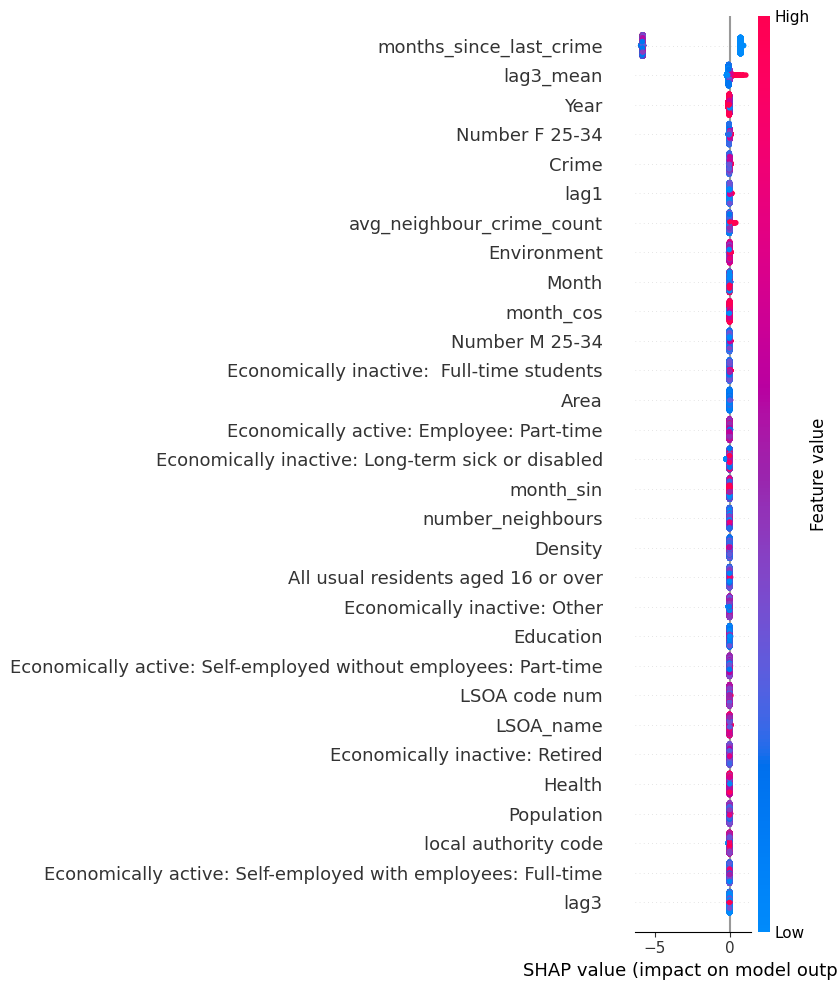

In [ ]:
# SHAP explainability

shap.initjs()  # enables JS visualisation in notebook

print("Computing SHAP values (this can take a minute)")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Beeswarm
shap.summary_plot(shap_values, X_test, max_display=30, plot_size=(8, 10))

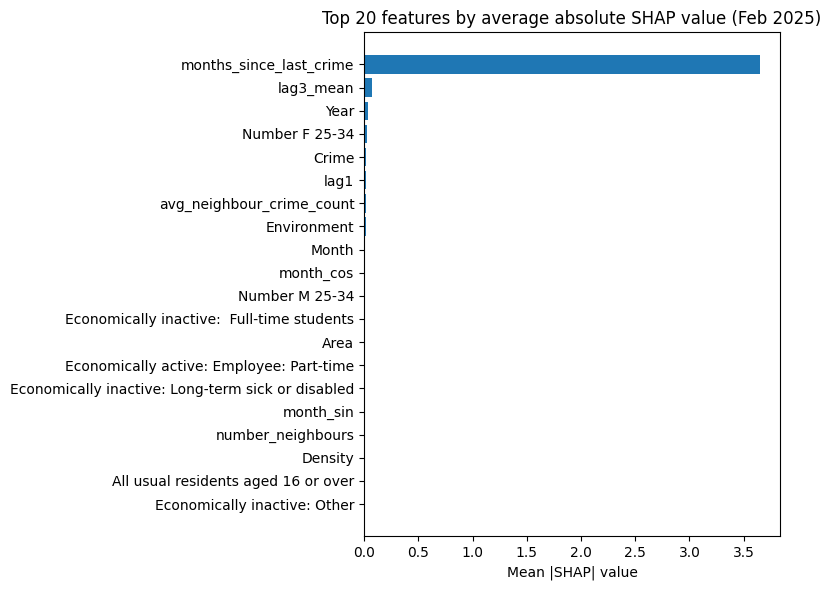

In [ ]:
# Bar chart of mean SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
bar_df = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs_shap})
bar_df = bar_df.sort_values("mean_abs_shap", ascending=True).tail(20)

plt.figure(figsize=(8, 6))
plt.barh(bar_df["feature"], bar_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP| value")
plt.title("Top 20 features by average absolute SHAP value (Feb 2025)")
plt.tight_layout()
plt.show()

Experimenting